In [1]:
!pip install -q scikit-learn pandas matplotlib

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [3]:
dados = pd.DataFrame({
    "Pessoa": [f"P{i}" for i in range(1, 21)],

    # idade em anos
    "Idade": [18, 20, 22, 25, 27, 30, 35, 38, 40, 42,
              50, 52, 55, 58, 60, 65, 68, 70, 72, 75],

    # horas de sono por noite
    "Sono": [8, 7, 8, 7, 6, 7, 6, 5, 6, 5,
             6, 5, 5, 4, 5, 4, 4, 5, 4, 3],

    # exposição a ambientes fechados por dia
    "AmbienteFechado": [1, 2, 1, 2, 3, 2, 5, 6, 5, 7,
                        6, 7, 8, 8, 7, 9, 9, 8, 10, 9],

    # frequência de atividade física semanal
    "AtividadeFisica": [5, 4, 5, 4, 3, 4, 2, 1, 2, 1,
                        2, 1, 1, 0, 1, 0, 0, 1, 0, 0],

    # número de sintomas recentes
    "Sintomas": [0, 1, 0, 1, 1, 0, 2, 3, 2, 3,
                 3, 4, 4, 5, 4, 5, 6, 5, 6, 7],

    # tomou vacina? 1 = sim, 0 = não
    "Vacinado": [1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
                 1, 0, 0, 0, 1, 0, 0, 1, 0, 0]
})

dados

,Pessoa,Idade,Sono,AmbienteFechado,AtividadeFisica,Sintomas,Vacinado
0,P1,18,8,1,5,0,1
1,P2,20,7,2,4,1,1
2,P3,22,8,1,5,0,1
3,P4,25,7,2,4,1,1
4,P5,27,6,3,3,1,0
5,P6,30,7,2,4,0,1
6,P7,35,6,5,2,2,1
7,P8,38,5,6,1,3,0
8,P9,40,6,5,2,2,1
9,P10,42,5,7,1,3,0


In [4]:
atributos = [
    "Idade",
    "Sono",
    "AmbienteFechado",
    "AtividadeFisica",
    "Sintomas",
    "Vacinado"
]

X = dados[atributos]

X.head()

,Idade,Sono,AmbienteFechado,AtividadeFisica,Sintomas,Vacinado
0,18,8,1,5,0,1
1,20,7,2,4,1,1
2,22,8,1,5,0,1
3,25,7,2,4,1,1
4,27,6,3,3,1,0


In [5]:
normalizador = StandardScaler()

X_normalizado = normalizador.fit_transform(X)

X_normalizado

array([[-1.53050018,  1.83803656, -1.649992  ,  1.87330826, -1.46298045,
         1.        ],
       [-1.42156778,  1.10282193, -1.30262526,  1.27860722, -0.99105127,
         1.        ],
       [-1.31263539,  1.83803656, -1.649992  ,  1.87330826, -1.46298045,
         1.        ],
       [-1.14923679,  1.10282193, -1.30262526,  1.27860722, -0.99105127,
         1.        ],
       [-1.04030439,  0.36760731, -0.95525853,  0.68390619, -0.99105127,
        -1.        ],
       [-0.8769058 ,  1.10282193, -1.30262526,  1.27860722, -1.46298045,
         1.        ],
       [-0.6045748 ,  0.36760731, -0.26052505,  0.08920516, -0.5191221 ,
         1.        ],
       [-0.44117621, -0.36760731,  0.08684168, -0.50549588, -0.04719292,
        -1.        ],
       [-0.33224381,  0.36760731, -0.26052505,  0.08920516, -0.5191221 ,
         1.        ],
       [-0.22331141, -0.36760731,  0.43420842, -0.50549588, -0.04719292,
        -1.        ],
       [ 0.21241817,  0.36760731,  0.08684168,  0.

In [6]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

dados["Cluster_KMeans"] = kmeans.fit_predict(X_normalizado)

dados[["Pessoa", "Cluster_KMeans"]]

,Pessoa,Cluster_KMeans
0,P1,2
1,P2,2
2,P3,2
3,P4,2
4,P5,2
5,P6,2
6,P7,1
7,P8,0
8,P9,1
9,P10,0


In [7]:
agnes = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

dados["Cluster_AGNES"] = agnes.fit_predict(X_normalizado)

dados[["Pessoa", "Cluster_AGNES"]]

,Pessoa,Cluster_AGNES
0,P1,1
1,P2,1
2,P3,1
3,P4,1
4,P5,0
5,P6,1
6,P7,0
7,P8,0
8,P9,0
9,P10,0


In [8]:
dbscan = DBSCAN(
    eps=1.6,
    min_samples=2
)

dados["Cluster_DBSCAN"] = dbscan.fit_predict(X_normalizado)

dados[["Pessoa", "Cluster_DBSCAN"]]

,Pessoa,Cluster_DBSCAN
0,P1,0
1,P2,0
2,P3,0
3,P4,0
4,P5,-1
5,P6,0
6,P7,1
7,P8,2
8,P9,1
9,P10,2


In [9]:
dados[[
    "Pessoa",
    "Idade",
    "Sono",
    "AmbienteFechado",
    "AtividadeFisica",
    "Sintomas",
    "Vacinado",
    "Cluster_KMeans",
    "Cluster_AGNES",
    "Cluster_DBSCAN"
]]

,Pessoa,Idade,Sono,AmbienteFechado,AtividadeFisica,Sintomas,Vacinado,Cluster_KMeans,Cluster_AGNES,Cluster_DBSCAN
0,P1,18,8,1,5,0,1,2,1,0
1,P2,20,7,2,4,1,1,2,1,0
2,P3,22,8,1,5,0,1,2,1,0
3,P4,25,7,2,4,1,1,2,1,0
4,P5,27,6,3,3,1,0,2,0,-1
5,P6,30,7,2,4,0,1,2,1,0
6,P7,35,6,5,2,2,1,1,0,1
7,P8,38,5,6,1,3,0,0,0,2
8,P9,40,6,5,2,2,1,1,0,1
9,P10,42,5,7,1,3,0,0,0,2


In [10]:
def calcular_silhouette(nome_algoritmo, labels):
    grupos = set(labels)

    # Silhouette não funciona se houver apenas 1 grupo
    # ou se cada ponto formar seu próprio grupo
    if len(grupos) <= 1:
        return None

    # No DBSCAN, -1 representa ruído.
    # Aqui vamos calcular somente se houver pelo menos 2 grupos reais.
    grupos_reais = [g for g in grupos if g != -1]

    if len(grupos_reais) < 2:
        return None

    return silhouette_score(X_normalizado, labels)


resultados = pd.DataFrame({
    "Algoritmo": ["K-Means", "AGNES", "DBSCAN"],
    "Silhouette": [
        calcular_silhouette("K-Means", dados["Cluster_KMeans"]),
        calcular_silhouette("AGNES", dados["Cluster_AGNES"]),
        calcular_silhouette("DBSCAN", dados["Cluster_DBSCAN"])
    ]
})

resultados

,Algoritmo,Silhouette
0,K-Means,0.475089
1,AGNES,0.416499
2,DBSCAN,0.458173


In [11]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_normalizado)

dados["PCA1"] = X_pca[:, 0]
dados["PCA2"] = X_pca[:, 1]

dados.head()

,Pessoa,Idade,Sono,AmbienteFechado,AtividadeFisica,Sintomas,Vacinado,Cluster_KMeans,Cluster_AGNES,Cluster_DBSCAN,PCA1,PCA2
0,P1,18,8,1,5,0,1,2,1,0,3.863627,-0.137058
1,P2,20,7,2,4,1,1,2,1,0,2.899374,0.015531
2,P3,22,8,1,5,0,1,2,1,0,3.774231,-0.054098
3,P4,25,7,2,4,1,1,2,1,0,2.787628,0.119232
4,P5,27,6,3,3,1,0,2,0,-1,1.392046,-1.603263


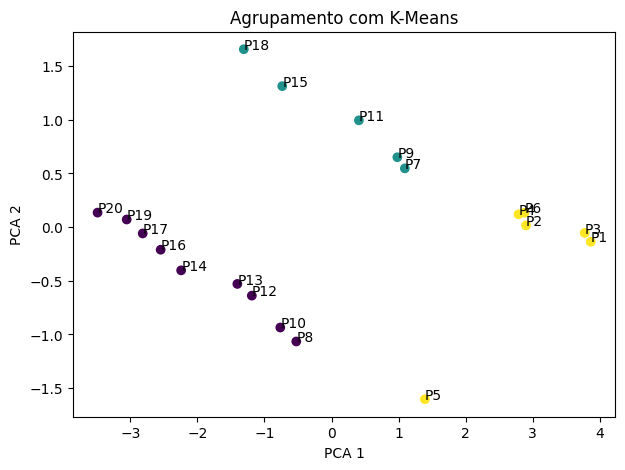

In [12]:
plt.figure(figsize=(7, 5))

plt.scatter(
    dados["PCA1"],
    dados["PCA2"],
    c=dados["Cluster_KMeans"]
)

for i, pessoa in enumerate(dados["Pessoa"]):
    plt.text(dados["PCA1"][i], dados["PCA2"][i], pessoa)

plt.title("Agrupamento com K-Means")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

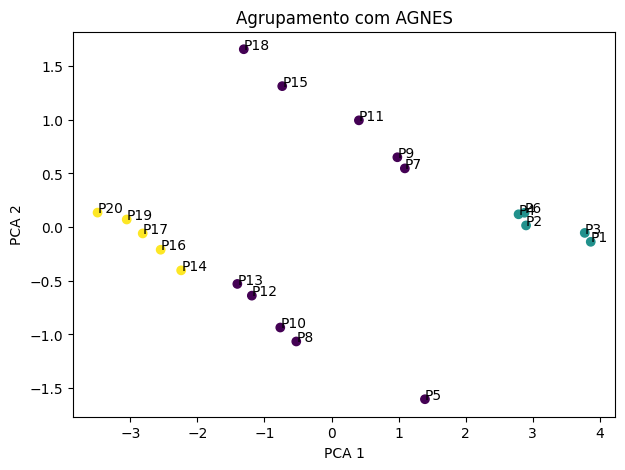

In [13]:
plt.figure(figsize=(7, 5))

plt.scatter(
    dados["PCA1"],
    dados["PCA2"],
    c=dados["Cluster_AGNES"]
)

for i, pessoa in enumerate(dados["Pessoa"]):
    plt.text(dados["PCA1"][i], dados["PCA2"][i], pessoa)

plt.title("Agrupamento com AGNES")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

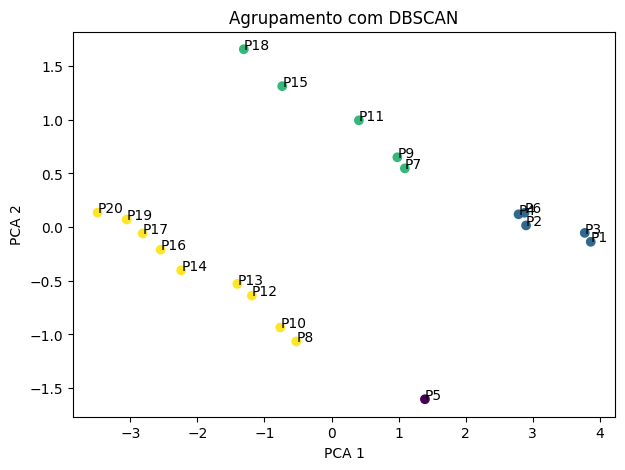

In [14]:
plt.figure(figsize=(7, 5))

plt.scatter(
    dados["PCA1"],
    dados["PCA2"],
    c=dados["Cluster_DBSCAN"]
)

for i, pessoa in enumerate(dados["Pessoa"]):
    plt.text(dados["PCA1"][i], dados["PCA2"][i], pessoa)

plt.title("Agrupamento com DBSCAN")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [15]:
perfil_kmeans = dados.groupby("Cluster_KMeans")[atributos].mean()

perfil_kmeans

,Idade,Sono,AmbienteFechado,AtividadeFisica,Sintomas,Vacinado
Cluster_KMeans,,,,,,
0,58.333333,4.333333,8.111111,0.444444,4.777778,0.000000
1,51.000000,5.600000,6.200000,1.600000,3.200000,1.000000
2,23.666667,7.166667,1.833333,4.166667,0.500000,0.833333


In [16]:
for cluster, linha in perfil_kmeans.iterrows():
    print(f"\nCluster {cluster} - K-Means")
    print(f"Idade média: {linha['Idade']:.1f}")
    print(f"Sono médio: {linha['Sono']:.1f} horas")
    print(f"Ambiente fechado: {linha['AmbienteFechado']:.1f} horas/dia")
    print(f"Atividade física: {linha['AtividadeFisica']:.1f} vezes/semana")
    print(f"Sintomas médios: {linha['Sintomas']:.1f}")
    print(f"Proporção vacinada: {linha['Vacinado']:.1f}")



Cluster 0 - K-Means
Idade média: 58.3
Sono médio: 4.3 horas
Ambiente fechado: 8.1 horas/dia
Atividade física: 0.4 vezes/semana
Sintomas médios: 4.8
Proporção vacinada: 0.0

Cluster 1 - K-Means
Idade média: 51.0
Sono médio: 5.6 horas
Ambiente fechado: 6.2 horas/dia
Atividade física: 1.6 vezes/semana
Sintomas médios: 3.2
Proporção vacinada: 1.0

Cluster 2 - K-Means
Idade média: 23.7
Sono médio: 7.2 horas
Ambiente fechado: 1.8 horas/dia
Atividade física: 4.2 vezes/semana
Sintomas médios: 0.5
Proporção vacinada: 0.8


In [17]:
perfil_agnes = dados.groupby("Cluster_AGNES")[atributos].mean()

perfil_agnes

,Idade,Sono,AmbienteFechado,AtividadeFisica,Sintomas,Vacinado
Cluster_AGNES,,,,,,
0,46.9,5.4,6.2,1.5,3.1,0.5
1,23.0,7.4,1.6,4.4,0.4,1.0
2,67.6,3.8,9.0,0.0,5.8,0.0


In [18]:
for cluster, linha in perfil_agnes.iterrows():
    print(f"\nCluster {cluster} - AGNES")
    print(f"Idade média: {linha['Idade']:.1f}")
    print(f"Sono médio: {linha['Sono']:.1f} horas")
    print(f"Ambiente fechado: {linha['AmbienteFechado']:.1f} horas/dia")
    print(f"Atividade física: {linha['AtividadeFisica']:.1f} vezes/semana")
    print(f"Sintomas médios: {linha['Sintomas']:.1f}")
    print(f"Proporção vacinada: {linha['Vacinado']:.1f}")


Cluster 0 - AGNES
Idade média: 46.9
Sono médio: 5.4 horas
Ambiente fechado: 6.2 horas/dia
Atividade física: 1.5 vezes/semana
Sintomas médios: 3.1
Proporção vacinada: 0.5

Cluster 1 - AGNES
Idade média: 23.0
Sono médio: 7.4 horas
Ambiente fechado: 1.6 horas/dia
Atividade física: 4.4 vezes/semana
Sintomas médios: 0.4
Proporção vacinada: 1.0

Cluster 2 - AGNES
Idade média: 67.6
Sono médio: 3.8 horas
Ambiente fechado: 9.0 horas/dia
Atividade física: 0.0 vezes/semana
Sintomas médios: 5.8
Proporção vacinada: 0.0


In [19]:
perfil_dbscan = dados.groupby("Cluster_DBSCAN")[atributos].mean()

perfil_dbscan

,Idade,Sono,AmbienteFechado,AtividadeFisica,Sintomas,Vacinado
Cluster_DBSCAN,,,,,,
-1,27.000000,6.000000,3.000000,3.000000,1.000000,0.0
0,23.000000,7.400000,1.600000,4.400000,0.400000,1.0
1,51.000000,5.600000,6.200000,1.600000,3.200000,1.0
2,58.333333,4.333333,8.111111,0.444444,4.777778,0.0


In [20]:
for cluster, linha in perfil_dbscan.iterrows():
    if cluster == -1:
        nome_cluster = "Ruído / caso atípico"
    else:
        nome_cluster = f"Cluster {cluster}"

    print(f"\n{nome_cluster} - DBSCAN")
    print(f"Idade média: {linha['Idade']:.1f}")
    print(f"Sono médio: {linha['Sono']:.1f} horas")
    print(f"Ambiente fechado: {linha['AmbienteFechado']:.1f} horas/dia")
    print(f"Atividade física: {linha['AtividadeFisica']:.1f} vezes/semana")
    print(f"Sintomas médios: {linha['Sintomas']:.1f}")
    print(f"Proporção vacinada: {linha['Vacinado']:.1f}")


Ruído / caso atípico - DBSCAN
Idade média: 27.0
Sono médio: 6.0 horas
Ambiente fechado: 3.0 horas/dia
Atividade física: 3.0 vezes/semana
Sintomas médios: 1.0
Proporção vacinada: 0.0

Cluster 0 - DBSCAN
Idade média: 23.0
Sono médio: 7.4 horas
Ambiente fechado: 1.6 horas/dia
Atividade física: 4.4 vezes/semana
Sintomas médios: 0.4
Proporção vacinada: 1.0

Cluster 1 - DBSCAN
Idade média: 51.0
Sono médio: 5.6 horas
Ambiente fechado: 6.2 horas/dia
Atividade física: 1.6 vezes/semana
Sintomas médios: 3.2
Proporção vacinada: 1.0

Cluster 2 - DBSCAN
Idade média: 58.3
Sono médio: 4.3 horas
Ambiente fechado: 8.1 horas/dia
Atividade física: 0.4 vezes/semana
Sintomas médios: 4.8
Proporção vacinada: 0.0


In [23]:
def interpretar_clusters(dados, coluna_cluster):
    perfis = dados.groupby(coluna_cluster)[atributos].mean()

    for cluster, linha in perfis.iterrows():
        print("=" * 60)

        if cluster == -1:
            print("Grupo -1: possíveis casos atípicos detectados pelo DBSCAN")
        else:
            print(f"Grupo {cluster}")

        interpretacao = []

        if linha["Idade"] >= 55:
            interpretacao.append("pessoas mais velhas")
        elif linha["Idade"] <= 30:
            interpretacao.append("pessoas mais jovens")
        else:
            interpretacao.append("pessoas de idade intermediária")

        if linha["Sono"] < 5:
            interpretacao.append("poucas horas de sono")
        elif linha["Sono"] >= 7:
            interpretacao.append("sono adequado")

        if linha["AmbienteFechado"] >= 7:
            interpretacao.append("alta exposição a ambientes fechados")
        elif linha["AmbienteFechado"] <= 3:
            interpretacao.append("baixa exposição a ambientes fechados")

        if linha["AtividadeFisica"] <= 1:
            interpretacao.append("baixa atividade física")
        elif linha["AtividadeFisica"] >= 4:
            interpretacao.append("alta atividade física")

        if linha["Sintomas"] >= 5:
            interpretacao.append("muitos sintomas recentes")
        elif linha["Sintomas"] <= 1:
            interpretacao.append("poucos sintomas recentes")

        if linha["Vacinado"] >= 0.7:
            interpretacao.append("maioria vacinada")
        elif linha["Vacinado"] <= 0.3:
            interpretacao.append("maioria não vacinada")

        print("Perfil:", ", ".join(interpretacao))

In [24]:
interpretar_clusters(dados, "Cluster_KMeans")

Grupo 0
Perfil: pessoas mais velhas, poucas horas de sono, alta exposição a ambientes fechados, baixa atividade física, maioria não vacinada
Grupo 1
Perfil: pessoas de idade intermediária, maioria vacinada
Grupo 2
Perfil: pessoas mais jovens, sono adequado, baixa exposição a ambientes fechados, alta atividade física, poucos sintomas recentes, maioria vacinada


In [25]:
interpretar_clusters(dados, "Cluster_AGNES")

Grupo 0
Perfil: pessoas de idade intermediária
Grupo 1
Perfil: pessoas mais jovens, sono adequado, baixa exposição a ambientes fechados, alta atividade física, poucos sintomas recentes, maioria vacinada
Grupo 2
Perfil: pessoas mais velhas, poucas horas de sono, alta exposição a ambientes fechados, baixa atividade física, muitos sintomas recentes, maioria não vacinada


In [26]:
interpretar_clusters(dados, "Cluster_DBSCAN")

Grupo -1: possíveis casos atípicos detectados pelo DBSCAN
Perfil: pessoas mais jovens, baixa exposição a ambientes fechados, poucos sintomas recentes, maioria não vacinada
Grupo 0
Perfil: pessoas mais jovens, sono adequado, baixa exposição a ambientes fechados, alta atividade física, poucos sintomas recentes, maioria vacinada
Grupo 1
Perfil: pessoas de idade intermediária, maioria vacinada
Grupo 2
Perfil: pessoas mais velhas, poucas horas de sono, alta exposição a ambientes fechados, baixa atividade física, maioria não vacinada
